# Notebook 7: Development-Only Calibration, Operating Thresholds & Model Search (post-holdout)

## 0. Scope & Governance
The 61-patient holdout was evaluated once in Notebook 6. That evaluation is final. **This notebook never loads holdout rows**; every number below comes from the 242 development patients using nested cross-validation.

It answers three questions:
1. **Are the v1 probabilities calibrated?** (Notebook 6 never checked.)
2. **Can the operating points be improved without touching the holdout?** At 0.50, v1 had LCX/RCA sensitivity of 0.34/0.20 in development CV.
3. **Can any model, ensemble or feature set beat the frozen champions?** About 30 candidates and 10 selection/ensembling procedures are evaluated with every selection made inside the inner loop.

**Rules declared before running (from the audit):**
- *Calibration*: Platt scaling on the logit of the frozen model output, fitted on inner out-of-fold predictions. It is strictly increasing, so ROC-AUC/AP, including the Notebook 6 holdout values, are unchanged.
- *Operating threshold*: Cath uses the highest threshold that keeps development sensitivity >= 0.90 (rule-out safety). Vessels use Youden's J. The threshold is chosen on inner out-of-fold calibrated probabilities and evaluated on the outer fold.
- *Model switch*: a new model/ensemble replaces a frozen champion only if its paired nested-CV ROC-AUC gain exceeds one Nadeau–Bengio-corrected SE **and** its Brier score is not worse. A switch also forfeits the holdout estimate for that target.

**Not permitted here:** evaluating any new model, calibration or threshold on the holdout. Getting an unbiased test estimate for v1.1 operating points or any new model requires new, untouched data.

In [1]:
import json, os, sys, hashlib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))
from ml import dev_search as ds

X_dev, y_dev, cfg, registry = ds.load_development()
TARGETS = cfg['target_columns']
assert len(X_dev) == 242 and not set(cfg['train_indices']) & set(cfg['holdout_indices'])
Path('artifacts/deployment').mkdir(parents=True, exist_ok=True)
Path('artifacts/dev_search').mkdir(parents=True, exist_ok=True)
Path('artifacts/figures/notebook7').mkdir(parents=True, exist_ok=True)
print(f"Development cohort: {len(X_dev)} patients | holdout rows loaded: 0")
print("Frozen champions:", {t: f"{registry[t]['selected_model']} ({registry[t]['preprocessing']})" for t in TARGETS})

Development cohort: 242 patients | holdout rows loaded: 0
Frozen champions: {'Cath': 'XGBoost (Config_B_OneHot)', 'LAD': 'RandomForest (Config_A_Ordinal)', 'LCX': 'RandomForest (Config_B_OneHot)', 'RCA': 'RandomForest (Config_B_OneHot)'}


## 1. Calibration Diagnostics of the Frozen v1 Configurations
5x5 repeated out-of-fold predictions of each frozen configuration on the development cohort. A calibration slope above 1 means the model is **underconfident**: its probabilities are squeezed toward the middle. The frozen hyperparameters were chosen on all 242 patients, so these estimates are mildly optimistic for discrimination; calibration shape is the point here.

In [2]:
frozen_oof = {t: ds.frozen_config_oof(t) for t in TARGETS}

diag = []
for t in TARGETS:
    s, y = frozen_oof[t]
    diag.append({'Target': t, 'Prevalence': y.mean(), 'Mean predicted': s.mean(),
                 'Calibration slope': ds.calibration_slope(y, s), 'Brier': np.mean((s - y) ** 2),
                 'Brier (prevalence only)': y.mean() * (1 - y.mean()),
                 '5th-95th pct of predictions': f"{np.percentile(s, 5):.2f} - {np.percentile(s, 95):.2f}",
                 'Predicted positive @0.50': (s >= 0.5).mean()})
display(pd.DataFrame(diag).round(3))

,Target,Prevalence,Mean predicted,Calibration slope,Brier,Brier (prevalence only),5th-95th pct of predictions,Predicted positive @0.50
0,Cath,0.715,0.718,1.206,0.096,0.204,0.11 - 0.99,0.747
1,LAD,0.591,0.568,1.893,0.162,0.242,0.22 - 0.84,0.653
2,LCX,0.384,0.386,1.853,0.204,0.237,0.20 - 0.58,0.188
3,RCA,0.388,0.387,2.265,0.214,0.238,0.25 - 0.54,0.107


## 2. Broad Nested Search ("try everything", honestly)
**Candidates** (each with and without the Diamond–Forrester pre-test-probability feature):
- L2 logistic regression (C = 0.03 / 0.1 / 0.3) and L1 logistic regression.
- The frozen champion configuration, Random Forest, class-balanced Random Forest and ExtraTrees.
- Shallow XGBoost, XGBoost with the Cath configuration, LightGBM and CatBoost.
- RBF SVM and a small MLP.
- For vessels only: a coherent hierarchy P(vessel) = P(CAD) x P(vessel | CAD).

**Procedures:** these are the ways of choosing or combining candidates, all decided inside each outer training fold via 5-fold inner CV. See `ds.PROCEDURES`.

**Outer loop:** 5x5 repeated stratified CV (the same folds as Notebooks 3/4), paired across procedures. This takes roughly 15 minutes on 20 cores.

In [3]:
n_jobs = max(1, (os.cpu_count() or 2) - 2)
raw = ds.run_search(n_jobs=n_jobs, verbose=0)
fold_df, pooled = ds.evaluate_procedures(raw)
summary = ds.summarise(fold_df, pooled)
fold_df.to_csv('artifacts/dev_search/procedure_fold_results.csv', index=False)
summary.to_csv('artifacts/dev_search/procedure_summary.csv', index=False)
pd.Series(ds.PROCEDURES, name='description').to_csv('artifacts/dev_search/procedure_descriptions.csv')
print(f"Evaluated {len(ds.candidate_names('LAD'))} vessel / {len(ds.candidate_names('Cath'))} Cath candidates x {len(ds.PROCEDURES)} procedures x 25 outer folds.")

Evaluated 30 vessel / 28 Cath candidates x 10 procedures x 25 outer folds.


### 2.1 Discrimination (paired against the shipped v1 champion on 25 identical outer folds)

In [4]:
cols = ['target', 'procedure', 'ROC_AUC', 'dAUC_vs_shipped', 'SE_dAUC', 'p_dAUC', 'folds_better', 'AP']
with pd.option_context('display.max_rows', 60):
    display(summary[cols].round(4))

,target,procedure,ROC_AUC,dAUC_vs_shipped,SE_dAUC,p_dAUC,folds_better,AP
0,Cath,S0_shipped@0.50,0.9285,0.0000,0.0000,1.0000,0,0.9680
1,Cath,S0c_champion+Platt,0.9285,0.0000,0.0000,1.0000,0,0.9665
2,Cath,S1_best_single,0.9231,-0.0055,0.0114,0.6363,10,0.9661
3,Cath,S2_top3_mean,0.9280,-0.0005,0.0109,0.9618,10,0.9669
4,Cath,S3_top5_mean,0.9281,-0.0004,0.0102,0.9676,11,0.9656
5,Cath,S4_all_mean,0.9413,0.0128,0.0095,0.1931,18,0.9725
6,Cath,S5_stacking,0.9352,0.0066,0.0106,0.5359,15,0.9720
7,Cath,S6_greedy_ensemble,0.9365,0.0079,0.0092,0.3975,16,0.9714
8,Cath,S7_fixed_trio,0.9360,0.0075,0.0099,0.4579,15,0.9703
9,Cath,S8_champion+DF,0.9272,-0.0013,0.0075,0.8587,9,0.9654


### 2.2 Probability quality (Brier score and calibration slope, pooled out-of-fold)

In [5]:
cols = ['target', 'procedure', 'Brier', 'dBrier_vs_v1.1', 'p_dBrier', 'calibration_slope']
with pd.option_context('display.max_rows', 60):
    display(summary[cols].round(4))

,target,procedure,Brier,dBrier_vs_v1.1,p_dBrier,calibration_slope
0,Cath,S0_shipped@0.50,0.0959,-0.0004,0.8814,1.2077
1,Cath,S0c_champion+Platt,0.0963,0.0000,1.0000,0.9665
2,Cath,S1_best_single,0.0987,0.0023,0.7978,0.8689
3,Cath,S2_top3_mean,0.0961,-0.0002,0.9835,0.8514
4,Cath,S3_top5_mean,0.0957,-0.0006,0.9396,0.8448
5,Cath,S4_all_mean,0.0866,-0.0097,0.1018,0.9476
6,Cath,S5_stacking,0.0914,-0.0049,0.5059,0.8796
7,Cath,S6_greedy_ensemble,0.0922,-0.0042,0.5188,0.8648
8,Cath,S7_fixed_trio,0.0898,-0.0065,0.3332,0.9545
9,Cath,S8_champion+DF,0.0971,0.0007,0.9149,0.9288


### 2.3 Operating point (pre-declared threshold rules; the shipped model uses 0.50 on uncalibrated output)

In [6]:
cols = ['target', 'procedure', 'mean_threshold', 'sd_threshold', 'sensitivity', 'specificity', 'PPV', 'NPV',
        'balanced_accuracy', 'MCC', 'F1', 'accuracy', 'F1_at_F1_rule']
with pd.option_context('display.max_rows', 60):
    display(summary[cols].round(3))

,target,procedure,mean_threshold,sd_threshold,sensitivity,specificity,PPV,NPV,balanced_accuracy,MCC,F1,accuracy,F1_at_F1_rule
0,Cath,S0_shipped@0.50,0.500,0.000,0.924,0.696,0.884,0.785,0.810,0.644,0.903,0.859,0.903
1,Cath,S0c_champion+Platt,0.539,0.068,0.904,0.739,0.897,0.755,0.822,0.648,0.900,0.857,0.900
2,Cath,S1_best_single,0.565,0.049,0.902,0.797,0.918,0.765,0.849,0.690,0.910,0.872,0.906
3,Cath,S2_top3_mean,0.571,0.050,0.902,0.794,0.917,0.764,0.848,0.688,0.909,0.871,0.912
4,Cath,S3_top5_mean,0.582,0.047,0.898,0.788,0.914,0.756,0.843,0.678,0.906,0.867,0.902
5,Cath,S4_all_mean,0.593,0.039,0.912,0.794,0.917,0.783,0.853,0.703,0.915,0.879,0.911
6,Cath,S5_stacking,0.563,0.066,0.908,0.786,0.914,0.772,0.847,0.689,0.911,0.873,0.908
7,Cath,S6_greedy_ensemble,0.599,0.045,0.898,0.806,0.921,0.760,0.852,0.692,0.909,0.872,0.908
8,Cath,S7_fixed_trio,0.599,0.047,0.905,0.794,0.917,0.770,0.850,0.693,0.911,0.874,0.917
9,Cath,S8_champion+DF,0.543,0.061,0.895,0.754,0.901,0.741,0.824,0.645,0.898,0.855,0.902


### 2.4 Selection instability
The single candidate chosen by the inner loop changes from fold to fold, and the "best single model" procedure (S1) does not beat the champion. With N=242, picking a winner by CV mostly selects noise. The leaderboard below averages each candidate's outer AUC; it is **descriptive only**, since choosing from it would reintroduce selection bias.

In [7]:
for t in TARGETS:
    picks = pd.Series([pooled[(t, k, 'selected_single')] for k in range(25)]).value_counts().head(5)
    print(f"{t}: inner-loop single-model picks -> {picks.to_dict()}")
board = pd.DataFrame({t: {c: np.mean([pooled[(t, k, 'candidate', c)] for k in range(25)]) for c in ds.candidate_names(t)} for t in TARGETS})
board.to_csv('artifacts/dev_search/candidate_leaderboard_descriptive.csv')
display(board.round(4).sort_values('RCA', ascending=False).head(12))

Cath: inner-loop single-model picks -> {'champ|df': 4, 'lgbm|df': 3, 'rf|df': 3, 'catboost|df': 3, 'xgb_shallow|df': 3}
LAD: inner-loop single-model picks -> {'champ|df': 5, 'lr_l1_C0.3|base': 3, 'rf|df': 3, 'lr_l2_C0.03|df': 3, 'rf_bal|df': 3}
LCX: inner-loop single-model picks -> {'hier|df': 11, 'hier|base': 5, 'lr_l2_C0.03|df': 2, 'catboost|df': 2, 'rf|base': 2}
RCA: inner-loop single-model picks -> {'hier|df': 7, 'xgb_cathcfg|base': 4, 'hier|base': 3, 'lr_l2_C0.03|df': 3, 'lr_l1_C0.3|df': 2}


,Cath,LAD,LCX,RCA
lr_l2_C0.03|df,0.9318,0.8512,0.7361,0.7424
lr_l2_C0.1|df,0.9318,0.8438,0.7231,0.7395
lr_l1_C0.3|df,0.9285,0.8480,0.7186,0.7392
champ|df,0.9272,0.8614,0.7568,0.7374
lr_l2_C0.3|df,0.9277,0.8326,0.7054,0.7340
lr_l2_C0.1|base,0.9204,0.8283,0.7140,0.7302
hier|base,NaN,0.8359,0.7619,0.7298
hier|df,NaN,0.8454,0.7675,0.7286
lr_l2_C0.3|base,0.9259,0.8242,0.7013,0.7286
lr_l2_C0.03|base,0.9087,0.8266,0.7178,0.7252


## 3. Decision (pre-declared rule applied mechanically)
A procedure qualifies to replace the frozen champion for a target only if dAUC > 1 corrected SE **and** its Brier score is not worse than v1.1. Two further constraints apply to deployment:
- **Explainability:** the served model must have exact, real-time SHAP explanations. Ensembles containing SVM/MLP members need sampling-based explainers, which take seconds per request.
- **Governance:** a switched model has no holdout estimate.

In [8]:
dec = summary[~summary.procedure.isin(['S0_shipped@0.50', 'S0c_champion+Platt'])].copy()
dec['passes_rule'] = (dec['dAUC_vs_shipped'] > dec['SE_dAUC']) & (dec['dBrier_vs_v1.1'] <= 0)
display(dec[['target', 'procedure', 'dAUC_vs_shipped', 'SE_dAUC', 'dBrier_vs_v1.1', 'passes_rule']].round(4))
best = dec.loc[dec.groupby('target')['ROC_AUC'].idxmax(), ['target', 'procedure', 'ROC_AUC', 'dAUC_vs_shipped', 'p_dAUC']]
print("Numerically best procedure per target (descriptive):")
display(best.round(4))

,target,procedure,dAUC_vs_shipped,SE_dAUC,dBrier_vs_v1.1,passes_rule
2,Cath,S1_best_single,-0.0055,0.0114,0.0023,False
3,Cath,S2_top3_mean,-0.0005,0.0109,-0.0002,False
4,Cath,S3_top5_mean,-0.0004,0.0102,-0.0006,False
5,Cath,S4_all_mean,0.0128,0.0095,-0.0097,True
6,Cath,S5_stacking,0.0066,0.0106,-0.0049,False
7,Cath,S6_greedy_ensemble,0.0079,0.0092,-0.0042,False
8,Cath,S7_fixed_trio,0.0075,0.0099,-0.0065,False
9,Cath,S8_champion+DF,-0.0013,0.0075,0.0007,False
12,LAD,S1_best_single,-0.0047,0.0147,0.0016,False
13,LAD,S2_top3_mean,-0.0013,0.0104,-0.0017,False


Numerically best procedure per target (descriptive):


,target,procedure,ROC_AUC,dAUC_vs_shipped,p_dAUC
5,Cath,S4_all_mean,0.9413,0.0128,0.1931
15,LAD,S4_all_mean,0.8636,0.0082,0.3533
27,LCX,S6_greedy_ensemble,0.7602,0.0152,0.3648
35,RCA,S4_all_mean,0.7376,0.0169,0.3042


**Decision: deploy v1.1** (frozen v1 models + development-only Platt calibration + pre-declared operating thresholds) for all four targets.

- **What clears the rule:** the switch rule is a *necessary* condition (the audit phrased it as "adoption only counts if dAUC > 1 SE"). It is cleared by the mean of all calibrated candidates (S4) for Cath (+0.013, p = 0.19) and RCA (+0.017, p = 0.30), and by the top-3 mean (S2) for LCX (+0.015, p = 0.31). Nothing clears it for LAD.
- **Why that is weak evidence:** ten procedures were compared on four targets, so a few one-SE excursions are expected by chance. None of the gains is statistically significant.
- **Why the ensembles are not deployed:**
  - They contain SVM/MLP members, which cannot be explained exactly in real time. That would break the clinical-explanation requirement.
  - They have no holdout estimate, whereas the Notebook 6 holdout ROC-AUC/AP remain valid for v1.1.
- **Where the gains come from instead:** calibration and thresholding, which apply to the frozen models. Vessel calibration slopes move from about 1.9–2.3 to about 1.0, and LCX/RCA sensitivity and F1 roughly double.
- **How S4 is reported:** as the estimated performance ceiling for this dataset (about +0.01–0.02 ROC-AUC), not as the deployed model.

## 4. Final v1.1 Post-processing on All 242 Development Patients
Platt parameters are fitted on the pooled 5x5 out-of-fold predictions of each frozen configuration (Section 1). Operating thresholds come from the pre-declared rule applied to those calibrated out-of-fold probabilities. The frozen `.joblib` files are not modified; their SHA-256 hashes are recorded so the backend can verify it applies the calibration to exactly these models.

In [9]:
post = {}
for t in TARGETS:
    s, y = frozen_oof[t]
    ab = ds.fit_platt(s, y)
    assert ab is not None, f"Non-increasing calibration for {t}"
    cal = ds.apply_platt(s, ab)
    thr = ds.operating_threshold(t, cal, y)
    path = Path(f"artifacts/models/{t.lower()}_final_pipeline.joblib")
    v11 = summary[(summary.target == t) & (summary.procedure == 'S0c_champion+Platt')].iloc[0]
    v1 = summary[(summary.target == t) & (summary.procedure == 'S0_shipped@0.50')].iloc[0]
    metrics = lambda r: {k: round(float(r[k]), 4) for k in ['ROC_AUC', 'AP', 'Brier', 'calibration_slope', 'sensitivity', 'specificity',
                                                               'PPV', 'NPV', 'balanced_accuracy', 'MCC', 'F1', 'accuracy']}
    post[t] = {
        'pipeline_path': str(path).replace('\\', '/'),
        'pipeline_sha256': hashlib.sha256(path.read_bytes()).hexdigest(),
        'calibration': {'method': 'platt_on_logit', 'a': ab[0], 'b': ab[1], 'fitted_on': '5x5 repeated OOF predictions, 242 development patients'},
        'operating_threshold': thr,
        'threshold_rule': ds.THRESHOLD_RULES[t],
        'development_nested_cv': {'v1_shipped_at_0.50': metrics(v1), 'v1_1_calibrated_at_operating_threshold': metrics(v11)},
    }
    print(f"{t}: Platt a={ab[0]:.3f} b={ab[1]:+.3f} | operating threshold (calibrated) = {thr:.3f} | {ds.THRESHOLD_RULES[t]}")

Cath: Platt a=1.206 b=-0.140 | operating threshold (calibrated) = 0.562 | highest threshold with development sensitivity >= 0.90 (rule-out safety)
LAD: Platt a=1.893 b=-0.083 | operating threshold (calibrated) = 0.549 | Youden's J (maximise sensitivity + specificity)
LCX: Platt a=1.853 b=+0.338 | operating threshold (calibrated) = 0.374 | Youden's J (maximise sensitivity + specificity)
RCA: Platt a=2.265 b=+0.554 | operating threshold (calibrated) = 0.372 | Youden's J (maximise sensitivity + specificity)


## 5. Does Each Colour Band Mean What It Says? (3D legend validity)
Observed stenosis frequency within calibrated-probability bands. It uses the **nested** outer-fold v1.1 predictions (S0c), averaged over the 5 repeats. If the colour scale is honest, the observed rate should fall inside or near each band.

In [10]:
bands = [0, 0.2, 0.4, 0.6, 0.8, 1.0001]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
rows = []
for t in TARGETS:
    y = y_dev[t].values
    for r in range(5):
        prob = np.zeros(len(y))
        for k in range(r * 5, r * 5 + 5):
            va, pv, _, _ = pooled[(t, k, 'S0c_champion+Platt')]
            prob[va] = pv
        b = pd.cut(prob, bands, labels=labels, right=False)
        for lab in labels:
            m = np.asarray(b == lab)
            rows.append({'target': t, 'band': lab, 'repeat': r, 'n': int(m.sum()),
                         'mean_predicted': prob[m].mean() if m.any() else np.nan,
                         'observed_rate': y[m].mean() if m.any() else np.nan})
band_df = (pd.DataFrame(rows).groupby(['target', 'band'], observed=True)
           .agg(n_per_repeat=('n', 'mean'), mean_predicted=('mean_predicted', 'mean'), observed_rate=('observed_rate', 'mean'))
           .reset_index())
band_df = band_df[band_df.n_per_repeat > 0]
band_df.round(3).to_csv('artifacts/deployment/probability_band_validity.csv', index=False)
display(band_df.round(3))

,target,band,n_per_repeat,mean_predicted,observed_rate
0,Cath,0-20%,34.6,0.094,0.102
1,Cath,20-40%,21.4,0.285,0.355
2,Cath,40-60%,17.0,0.502,0.456
3,Cath,60-80%,22.0,0.711,0.637
4,Cath,80-100%,147.0,0.954,0.952
5,LAD,0-20%,41.6,0.105,0.129
6,LAD,20-40%,33.2,0.289,0.226
7,LAD,40-60%,27.6,0.503,0.523
8,LAD,60-80%,54.0,0.706,0.745
9,LAD,80-100%,85.6,0.901,0.883


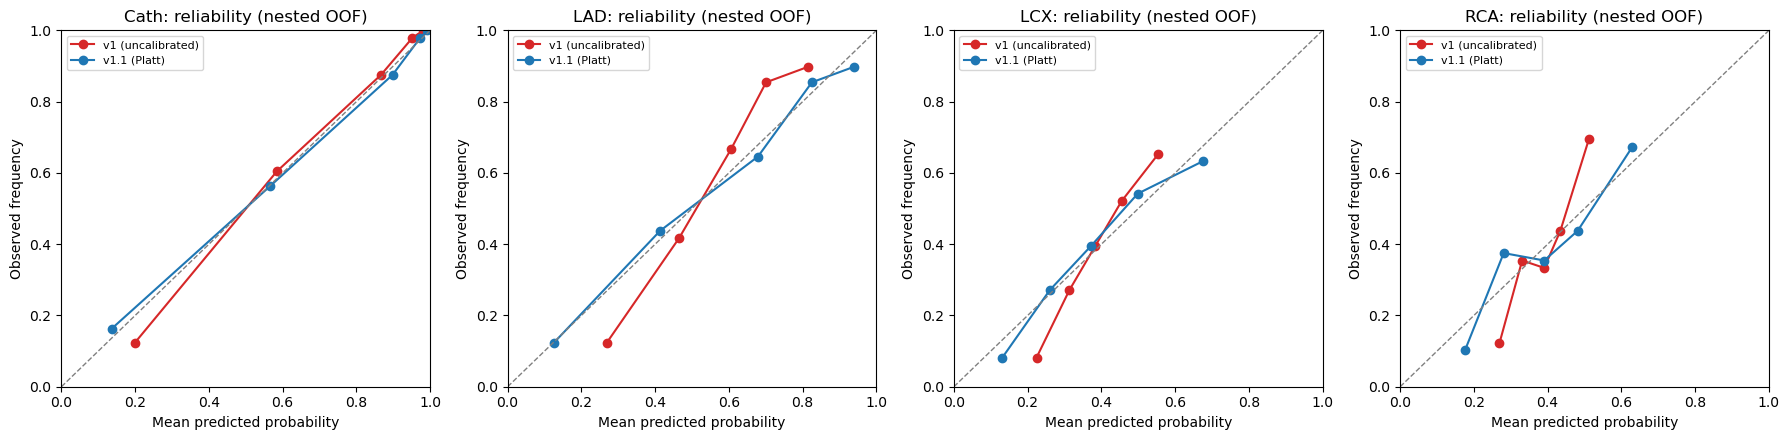

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, t in zip(axes, TARGETS):
    y = y_dev[t].values
    for proc, label, color in [('S0_shipped@0.50', 'v1 (uncalibrated)', '#d62728'), ('S0c_champion+Platt', 'v1.1 (Platt)', '#1f77b4')]:
        prob = np.zeros(len(y))
        for k in range(5):  # first repeat
            va, pv, _, _ = pooled[(t, k, proc)]
            prob[va] = pv
        q = pd.qcut(prob, 5, duplicates='drop')
        g = pd.DataFrame({'p': prob, 'y': y}).groupby(q, observed=True).mean()
        ax.plot(g['p'], g['y'], 'o-', color=color, label=label)
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
    ax.set_title(f"{t}: reliability (nested OOF)")
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('artifacts/figures/notebook7/reliability_v1_vs_v1_1.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Training Ranges for Out-of-Distribution Warnings

In [12]:
numeric = cfg['feature_groups']['all_numeric_features']  # includes BMI, Function Class and Region RWMA
ranges = {f: {'min': float(X_dev[f].min()), 'max': float(X_dev[f].max())} for f in numeric}
Path('artifacts/deployment/training_ranges.json').write_text(json.dumps(ranges, indent=2))
print(f"Saved development ranges for {len(ranges)} numeric features.")

Saved development ranges for 23 numeric features.


## 7. Export v1.1 Post-processing Artifact & Update the Manifest

In [13]:
artifact = {
    'version': '1.1.0',
    'created_by': '07_Development_Only_Improvements.ipynb',
    'holdout_used': False,
    'description': ('Frozen v1 pipelines + development-only Platt calibration + pre-declared operating thresholds. '
                    'Calibration is strictly increasing, so the Notebook 6 holdout ROC-AUC / AP apply unchanged; '
                    'threshold-dependent metrics are development nested-CV estimates.'),
    'decision_rule': 'switch model only if dAUC > 1 corrected SE and Brier not worse; switched models forfeit the holdout estimate',
    'targets': post,
}
Path('artifacts/deployment/v1_1_postprocessing.json').write_text(json.dumps(artifact, indent=2))

manifest_path = Path('artifacts/final_model_manifest.json')
manifest = json.loads(manifest_path.read_text())
manifest['v1_1_postprocessing'] = {
    'file': 'artifacts/deployment/v1_1_postprocessing.json',
    'holdout_used': False,
    'note': 'Holdout metrics in this manifest describe the frozen v1 models at 0.50; calibration does not change ROC-AUC or AP.'
}
manifest_path.write_text(json.dumps(manifest, indent=4))
print("Saved artifacts/deployment/v1_1_postprocessing.json and updated the manifest.")

Saved artifacts/deployment/v1_1_postprocessing.json and updated the manifest.


## 8. Summary: What Improved, and What Evidence Supports It

In [14]:
rows = []
for t in TARGETS:
    a = post[t]['development_nested_cv']['v1_shipped_at_0.50']
    b = post[t]['development_nested_cv']['v1_1_calibrated_at_operating_threshold']
    for m in ['ROC_AUC', 'Brier', 'calibration_slope', 'sensitivity', 'specificity', 'balanced_accuracy', 'MCC', 'F1']:
        rows.append({'Target': t, 'Metric': m, 'v1 @0.50': a[m], 'v1.1': b[m], 'Change': b[m] - a[m]})
final = pd.DataFrame(rows)
final.to_csv('artifacts/dev_search/v1_vs_v1_1_development.csv', index=False)
display(final.pivot(index='Metric', columns='Target', values='v1.1').round(3))
display(final.round(3))

Target,Cath,LAD,LCX,RCA
Metric,,,,
Brier,0.096,0.151,0.198,0.207
F1,0.900,0.816,0.617,0.597
MCC,0.648,0.551,0.335,0.283
ROC_AUC,0.928,0.856,0.745,0.721
balanced_accuracy,0.822,0.775,0.672,0.645
calibration_slope,0.966,0.950,0.961,1.026
sensitivity,0.904,0.818,0.701,0.698
specificity,0.739,0.731,0.643,0.592


,Target,Metric,v1 @0.50,v1.1,Change
0,Cath,ROC_AUC,0.928,0.928,0.000
1,Cath,Brier,0.096,0.096,0.000
2,Cath,calibration_slope,1.208,0.966,-0.241
3,Cath,sensitivity,0.924,0.904,-0.020
4,Cath,specificity,0.696,0.739,0.043
5,Cath,balanced_accuracy,0.810,0.822,0.012
6,Cath,MCC,0.644,0.648,0.004
7,Cath,F1,0.903,0.900,-0.003
8,LAD,ROC_AUC,0.856,0.856,0.000
9,LAD,Brier,0.162,0.151,-0.012


**Interpretation**
- ROC-AUC is identical by construction; the Notebook 6 holdout values (0.854 / 0.794 / 0.730 / 0.701) remain the only held-out discrimination estimates.
- Calibration and operating-point improvements are **development nested-CV estimates**. They were not, and must not be, re-measured on the already-used holdout.
- The broad search gives the realistic ceiling for these 242 patients: roughly +0.01–0.02 ROC-AUC from averaging many models, which is not statistically distinguishable from the frozen champions. More data, not more modelling, is the binding constraint.